In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [31]:
import os
print(os.getcwd())

c:\Users\regmi\OneDrive\Desktop\Telecom_Customer_Churn_G6\Predictive_Modeling


In [32]:
import os
os.listdir("../Data_Preparation")

['processed_data', 'Raw_Data', 'README.md']

In [33]:
os.listdir("../Data_Preparation/processed_data")

['preprocessed_telecom_churn.csv',
 'README.md',
 'X_test.csv',
 'X_train.csv',
 'y_test.csv',
 'y_train.csv']

In [34]:
import pandas as pd

X_train = pd.read_csv("../Data_Preparation/processed_data/X_train.csv")
X_test = pd.read_csv("../Data_Preparation/processed_data/X_test.csv")

y_train = pd.read_csv("../Data_Preparation/processed_data/y_train.csv")
y_test = pd.read_csv("../Data_Preparation/processed_data/y_test.csv")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 13)
Test shape: (1409, 13)


In [35]:
import pandas as pd

X_train = pd.read_csv("../Data_Preparation/processed_data/X_train.csv")
X_test = pd.read_csv("../Data_Preparation/processed_data/X_test.csv")

y_train = pd.read_csv("../Data_Preparation/processed_data/y_train.csv")
y_test = pd.read_csv("../Data_Preparation/processed_data/y_test.csv")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 13)
Test shape: (1409, 13)


In [36]:
model = Sequential()

model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\regmi\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6965 - loss: 0.5693 - val_accuracy: 0.7750 - val_loss: 0.4829
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7829 - loss: 0.4611 - val_accuracy: 0.7899 - val_loss: 0.4578
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7852 - loss: 0.4469 - val_accuracy: 0.7885 - val_loss: 0.4565
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7854 - loss: 0.4434 - val_accuracy: 0.7885 - val_loss: 0.4578
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7888 - loss: 0.4430 - val_accuracy: 0.7913 - val_loss: 0.4539
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7874 - loss: 0.4422 - val_accuracy: 0.7857 - val_loss: 0.4553
Epoch 7/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7870 - loss: 0.4416 - val_accuracy: 0.7956 - val_loss: 0.4525
Epoch 8/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7913 - loss: 0.4412 - val_accuracy: 0.

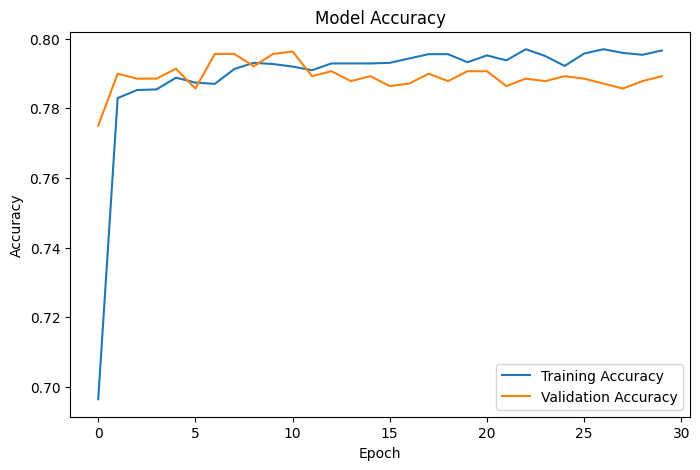

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

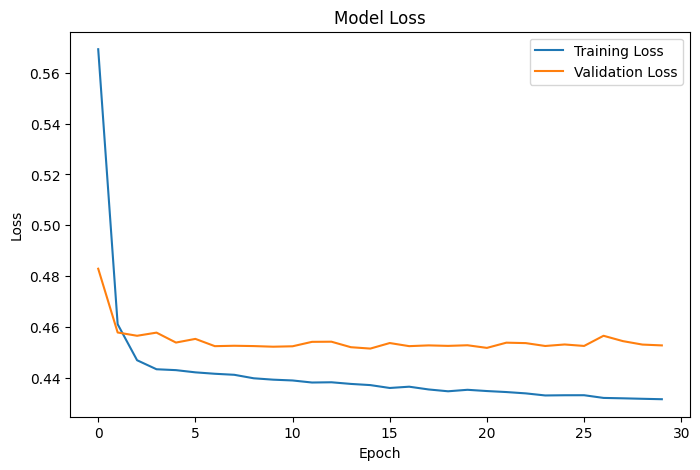

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


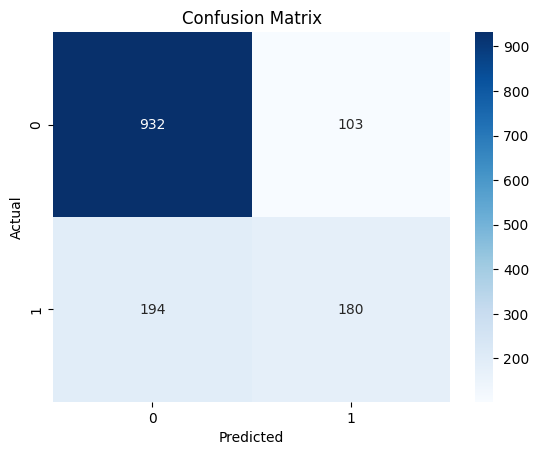

In [40]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

